# NeuralPOD-DeepONet


In [ ]:
import os, sys, pathlib
import numpy as np
import torch
import h5py
import matplotlib.pyplot as plt

sys.path.insert(0, str(pathlib.Path("..").resolve()))
from utils.datasets import load
from models.regime_basis import FourierRegimeBasis
from models.fourier_neural_pod import FourierNeuralPODTrainer, FourierNeuralPODConfig
from models.pod_deeponet import BranchNet
from models.neural_pod_deeponet import NeuralPODDeepONet, NeuralPODDeepONetConfig, NeuralPODDeepONetTrainer
from models.pod import PODTrainer, PODConfig
from models.pod_deeponet import PODDeepONet, PODDeepONetConfig, PODDeepONetTrainer, BranchNet

if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'

DATA_DIR = os.path.expanduser("~/data/1D/Burgers/Train")

def rel_l2(true, pred):
    return np.linalg.norm(true - pred, axis=1) / np.linalg.norm(true, axis=1)

**Problem.** Given initial condition $u_0(x) = u(x, 0)$, approximate the solution operator
$\mathcal{G}: u_0 \mapsto u(\cdot, \cdot)$ for a time-dependent PDE on $x \in \Omega$, $t \in [0, T]$.

NeuralPOD-DeepONet replaces the linear POD basis with a nonlinear Fourier basis,
retaining the two-phase training structure of POD-DeepONet (Lu et al., 2022).


#### Phase 1: Fourier Neural POD


Let $\{u^n\}_{n=1}^N$ be training trajectories, each flattened to $\mathbf{s}^n \in \mathbb{R}^{N_t N_x}$.
The spatiotemporal coordinate of point $j$ is $\mathbf{c}_j = (x_j, t_j) \in \mathbb{R}^2$.

The field is approximated as a sum of $K$ separable modes:
$$\mathbf{s}^n \approx \boldsymbol{\mu}(\mathbf{c}) + \sum_{k=1}^K \lambda_k^n \, \boldsymbol{\phi}_k(\mathbf{c})$$

where:
- $\boldsymbol{\mu}: \mathbb{R}^2 \to \mathbb{R}$ is a neural mean field, trained first on the empirical mean
- $\boldsymbol{\phi}_k: \mathbb{R}^2 \to \mathbb{R}$ is the $k$-th spatial mode, parameterized via Random Fourier Features:
$$\boldsymbol{\phi}_k(\mathbf{c}) = \mathrm{MLP}\bigl([\sin(2\pi B\mathbf{c}),\, \cos(2\pi B\mathbf{c})]\bigr), \quad B \in \mathbb{R}^{F \times 2} \text{ fixed random}$$
- $\lambda_k^n \in \mathbb{R}$ is a scalar coefficient — one per trajectory per mode

Modes are extracted **greedily**: each $(\boldsymbol{\phi}_k, \{\lambda_k^n\})$ is trained to minimize the weighted residual
$$\mathcal{L}_k = \sum_{n=1}^N \gamma_n \sum_j w_j \bigl(\lambda_k^n \, \phi_k(\mathbf{c}_j) - r_j^n\bigr)^2$$
where $\mathbf{r}^n$ is the residual after subtracting the previous $k{-}1$ modes.
After training mode $k$, its parameters are frozen and the residual is deflated.


#### Phase 2: Branch Network


After Phase 1, the coefficient matrix $\Lambda \in \mathbb{R}^{N \times K}$ with $\Lambda_{nk} = \lambda_k^n$
encodes how each training trajectory projects onto the learned modes.

A branch network $\mathcal{B}_\theta: \mathbb{R}^m \to \mathbb{R}^K$ is trained to predict
these coefficients from the initial condition sampled at $m$ sensor points:
$$\hat{\boldsymbol{\lambda}}^n = \mathcal{B}_\theta\bigl(u_0^n(x_1), \ldots, u_0^n(x_m)\bigr)$$

Training minimizes MSE against Phase 1 coefficients:
$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{n=1}^N \bigl\|\mathcal{B}_\theta(u_0^n) - \boldsymbol{\lambda}^n\bigr\|_2^2$$

The mode networks $\boldsymbol{\phi}_k$ and mean $\boldsymbol{\mu}$ are not updated in this phase.

---

#### Prediction

For a new initial condition $u_0^*$, the full spatiotemporal field is:
$$\hat{u}(\mathbf{c}) = \boldsymbol{\mu}(\mathbf{c}) + \sum_{k=1}^K \bigl[\mathcal{B}_\theta(u_0^*)\bigr]_k \, \boldsymbol{\phi}_k(\mathbf{c})$$

Unlike POD-DeepONet, the modes are not stored as fixed vectors — they are evaluated
by forward passes through $\boldsymbol{\phi}_k$ at query coordinates $\mathbf{c}$.
The result is reshaped from $\mathbb{R}^{N_t N_x}$ to $(N_t, N_x)$.


In [2]:
_local = pathlib.Path("..") / "data" / "Burgers_Nu1.0.hdf5"
_server = pathlib.Path(os.path.expanduser("~/data/1D/Burgers/Train")) / "1D_Burgers_Sols_Nu1.0.hdf5"
path = str(_local) if _local.exists() else str(_server)
print(f"data: {path}")

N_train, N_test = 2500, 500

with h5py.File(path, 'r') as f:
    raw = f['tensor'][:N_train + N_test]
    if raw.ndim == 4:
        raw = raw[..., 0]
    x_np = f['x-coordinate'][:]
    t_np = f['t-coordinate'][:]

N_total, Nt, Nx = raw.shape
t_np = t_np[:Nt]
print(f"loaded: N={N_total}, Nt={Nt}, Nx={Nx}")


data: ../data/Burgers_Nu1.0.hdf5
loaded: N=3000, Nt=256, Nx=101


In [ ]:
tensor_train = raw[:N_train]  # (N_train, Nt, Nx)
tensor_test = raw[N_train:]   # (N_test, Nt, Nx)
del raw

In [ ]:
# Flatten trajectories to (N, Nt*Nx); keep on CPU for trajectory batching
s_traj = torch.tensor(tensor_train.reshape(N_train, -1), dtype=torch.float32)  # (N_train, Nt*Nx)
u0_train = torch.tensor(tensor_train[:, 0, :], dtype=torch.float32).to(DEVICE)  # (N_train, Nx)
u0_test = torch.tensor(tensor_test[:, 0, :], dtype=torch.float32).to(DEVICE)    # (N_test, Nx)

# (x, t) coordinate pairs: col 0 = x, col 1 = t
x_grid = torch.tensor(x_np, dtype=torch.float32)
t_grid = torch.tensor(t_np, dtype=torch.float32)
tt, xx = torch.meshgrid(t_grid, x_grid, indexing='ij')  # (Nt, Nx)
x_flat = torch.stack([xx.flatten(), tt.flatten()], dim=1).to(DEVICE)  # (Nt*Nx, 2)

sensor_stride = 1
m = len(range(0, Nx, sensor_stride))
print(f"s_traj: {tuple(s_traj.shape)}, x_flat: {tuple(x_flat.shape)}, m={m}")

In [5]:
w     = torch.ones(Nt * Nx, dtype=torch.float32).to(DEVICE) / (Nt * Nx)
basis = FourierRegimeBasis(
    d_x=2, M=N_train, quad_weights=w,
    hidden_dim=256,
    num_frequencies=96,       # more features
    scales=[0.5, 2.0, 6.0],   # multi-scale: global / mid / local
    n_layers=3,               # deeper phi network
).to(DEVICE)

cfg_pod = FourierNeuralPODConfig(
    max_modes=20,
    n_epochs_mean=800,
    n_epochs_mode=1200,
)
trainer_pod = FourierNeuralPODTrainer(basis, cfg_pod)
history_pod = trainer_pod.train(s_traj, x_flat, t=None)

Fourier NeuralPOD | N=2500, Ny=25856 | max_modes=20 | traj_batch=256


mean:   0%|          | 0/800 [00:00<?, ?it/s]

mode 1:   0%|          | 0/1200 [00:00<?, ?it/s]

  mode 1: weighted_res=8.2623e-03


mode 2:   0%|          | 0/1200 [00:00<?, ?it/s]

...

  mode 18: weighted_res=1.7389e-03


mode 19:   0%|          | 0/1200 [00:00<?, ?it/s]

  mode 19: weighted_res=1.7076e-03


mode 20:   0%|          | 0/1200 [00:00<?, ?it/s]

  mode 20: weighted_res=1.6969e-03
  done: 20 modes



In [ ]:
K = basis.num_modes
branch = BranchNet(m=m, P=K, hidden_dim=256, n_layers=5).to(DEVICE)
model = NeuralPODDeepONet(basis, branch).to(DEVICE)

cfg = NeuralPODDeepONetConfig(n_epochs=80000, batch_size=512, sensor_stride=sensor_stride)
trainer = NeuralPODDeepONetTrainer(model, cfg)
history_branch = trainer.train(u0_train)

### Results

In [ ]:
# Phase 1: classical POD (for comparison)
pod_trainer = PODTrainer(PODConfig(max_modes=32, tol=0.9999))
pod_trainer.train(s_traj, x_flat, t=None)
print(f"POD modes: {pod_trainer.num_modes}")

coeffs = pod_trainer.basis.coeffs.numpy()
modes = pod_trainer.basis.modes.numpy()
mean = pod_trainer.basis.mean.numpy()
s_pred_pod = mean + coeffs @ modes.T
err_pod_p1 = rel_l2(s_traj.numpy(), s_pred_pod)
print(f"POD Phase 1 reconstruction | mean={err_pod_p1.mean():.4f}")

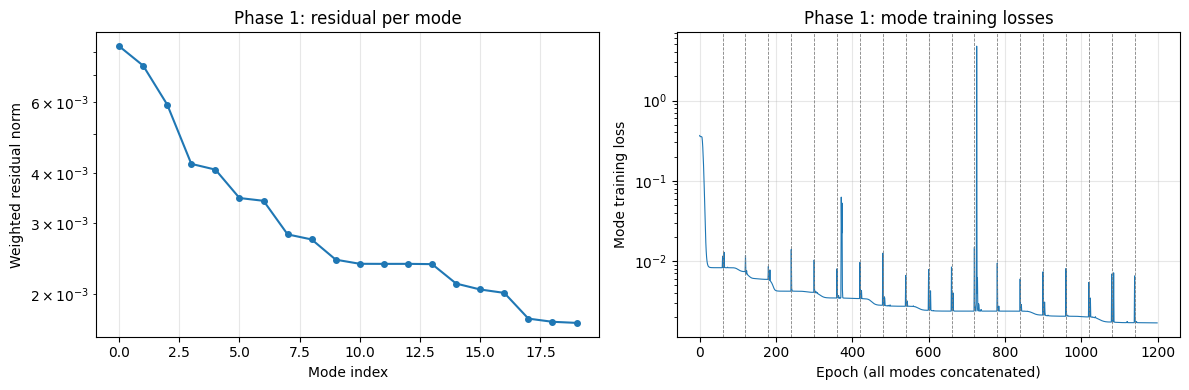

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogy(history_pod.residual_norms, 'o-', markersize=4)
ax.set_xlabel('Mode index')
ax.set_ylabel('Weighted residual norm')
ax.set_title('Phase 1: residual per mode')
ax.grid(True, alpha=0.3)

ax = axes[1]
logs = [v for sublist in history_pod.mode_losses for v in sublist]
ax.semilogy(logs, lw=0.8)
lengths = [len(ml) for ml in history_pod.mode_losses]
boundaries = [sum(lengths[:i]) for i in range(1, len(lengths) + 1)]
for b in boundaries[:-1]:
    ax.axvline(b, color='gray', lw=0.6, ls='--')
ax.set_xlabel('Epoch (all modes concatenated)')
ax.set_ylabel('Mode training loss')
ax.set_title('Phase 1: mode training losses')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


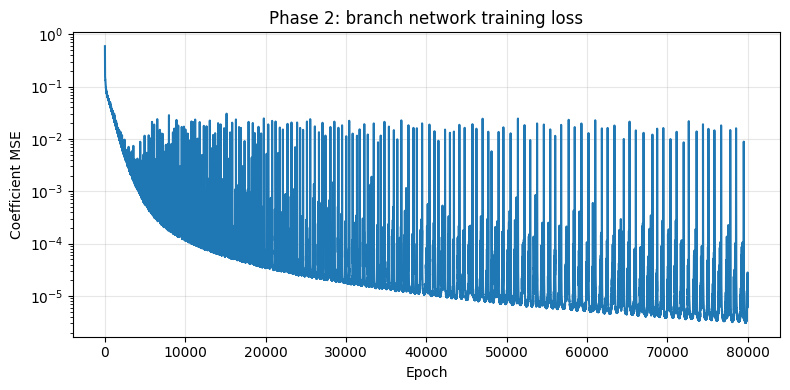

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(history_branch)
ax.set_xlabel('Epoch')
ax.set_ylabel('Coefficient MSE')
ax.set_title('Phase 2: branch network training loss')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
true_train = s_traj.cpu().numpy()
pred_train = trainer.predict(u0_train, x_flat).cpu().numpy()

true_test = tensor_test.reshape(N_test, -1)
pred_test = trainer.predict(u0_test, x_flat).cpu().numpy()

err_train = rel_l2(true_train, pred_train)
err_test = rel_l2(true_test, pred_test)

print(f"Train | mean={err_train.mean():.4f}  median={np.median(err_train):.4f}  std={err_train.std():.4f}")
print(f"Test  | mean={err_test.mean():.4f}  median={np.median(err_test):.4f}  std={err_test.std():.4f}  p95={np.percentile(err_test, 95):.4f}")

In [ ]:
rng = np.random.default_rng(42)
idxs = rng.choice(N_test, size=3, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for row, idx in enumerate(idxs):
    pred = trainer.predict(u0_test[idx:idx+1], x_flat).reshape(Nt, Nx).cpu().numpy()
    true = tensor_test[idx]
    err = np.abs(true - pred)
    vmax = np.abs(true).max()
    rl2 = np.linalg.norm(true - pred) / np.linalg.norm(true)

    for col, (arr, title, cmap, vmin, vm) in enumerate([
        (true, 'Ground Truth',       'RdBu_r', -vmax, vmax),
        (pred, 'NeuralPOD-DeepONet', 'RdBu_r', -vmax, vmax),
        (err,  'Absolute Error',      'Reds',    0,    err.max()),
    ]):
        ax = axes[row, col]
        im = ax.imshow(arr, aspect='auto', origin='lower', cmap=cmap,
                       extent=[x_np.min(), x_np.max(), t_np.min(), t_np.max()],
                       vmin=vmin, vmax=vm)
        if row == 0:
            ax.set_title(title, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f't   (rel L2={rl2:.3f})')
        if row == 2:
            ax.set_xlabel('x')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('NeuralPOD-DeepONet: reconstruction examples', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(err_test, bins=30, edgecolor='k', alpha=0.75)
ax.axvline(err_test.mean(), color='crimson', ls='--', lw=1.5, label=f'Mean {err_test.mean():.4f}')
ax.axvline(np.median(err_test), color='steelblue', ls='--', lw=1.5, label=f'Median {np.median(err_test):.4f}')
ax.set_xlabel('Relative L2 error')
ax.set_ylabel('Count')
ax.set_title('Test error distribution')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(np.sort(err_test), lw=1.5)
ax.axhline(err_test.mean(), color='crimson', ls='--', lw=1.2, alpha=0.8)
ax.set_xlabel('Trajectory rank')
ax.set_ylabel('Relative L2 error')
ax.set_title('Sorted test errors')
ax.grid(True, alpha=0.3)

plt.suptitle('NeuralPOD-DeepONet -- test set errors', fontweight='bold')
plt.tight_layout()
plt.show()